# Sample Size & Reliability Analysis

This notebook explores the statistical power of the side-channel attack. specifically: **How many receipts do we need to collect to confidently determine the user's state?**

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats

# Add simulator to path
sys.path.append(os.path.abspath("../simulator"))

from receipt_generator import ReceiptGenerator
from device_state_model import DeviceState, DeviceStateModel, DEFAULT_DEVICE_STATES
from network_delay_model import NetworkDelayModel, CELLULAR

## 1. Setup Simulation

We will use a `CELLULAR` network because it has moderate jitter, making the classification harder than WiFi but more realistic for mobile users.

In [2]:
network_model = NetworkDelayModel(profile=CELLULAR, seed=101)
device_model = DeviceStateModel(state_profiles=DEFAULT_DEVICE_STATES, seed=101)
generator = ReceiptGenerator(device_model=device_model, network_model=network_model)

# Ground Truth Means (approximate for analysis)
# Active ~65ms (Network) + 5ms (Device) + 65ms (Return) ~= 135ms
# Idle ~65ms + 40ms + 65ms ~= 170ms

## 2. Convergence of the Mean

We collect samples and plot the Cumulative Moving Average (CMA) to see how quickly the observed RTT converges to the true state mean.

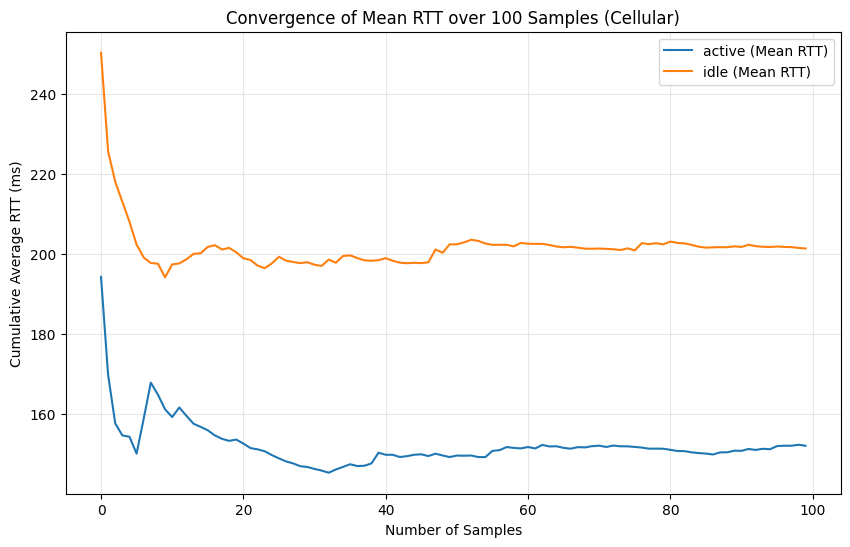

In [3]:
MAX_SAMPLES = 100

states_to_test = [DeviceState.ACTIVE, DeviceState.IDLE]
history = {state: [] for state in states_to_test}

for state in states_to_test:
    for _ in range(MAX_SAMPLES):
        rtt = generator.generate_receipt(state)
        if rtt:
            history[state].append(rtt)

plt.figure(figsize=(10, 6))

for state in states_to_test:
    data = np.array(history[state])
    cma = np.cumsum(data) / (np.arange(len(data)) + 1)
    plt.plot(cma, label=f"{state.value} (Mean RTT)")
    
plt.title(f"Convergence of Mean RTT over {MAX_SAMPLES} Samples (Cellular)")
plt.xlabel("Number of Samples")
plt.ylabel("Cumulative Average RTT (ms)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Confidence Interval Analysis

If we take N samples, how confident are we that the user is Active vs Idle? 

We can simulate N trials multiple times to see the spread of predicted means.

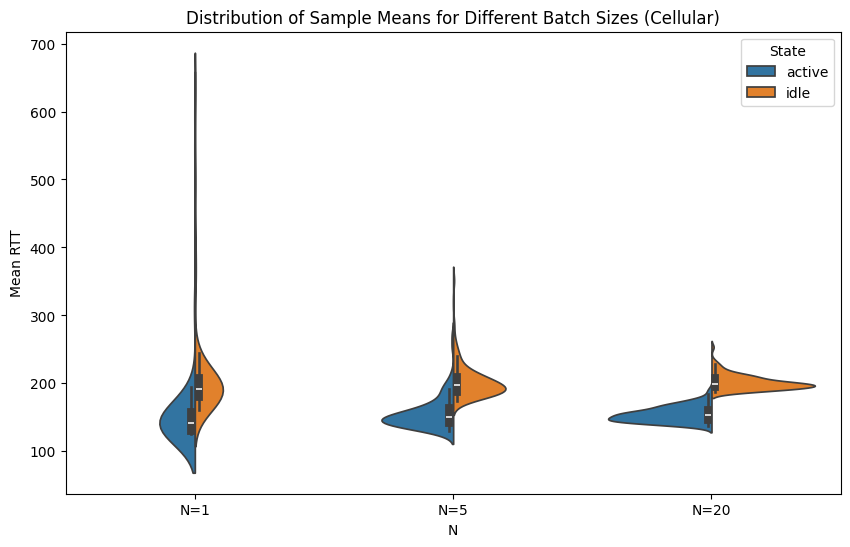

In [4]:
sample_sizes = [1, 5, 20]
trials_per_size = 100

trial_data = []

for n in sample_sizes:
    for state in states_to_test:
        for _ in range(trials_per_size):
            sample_mean = np.mean([generator.generate_receipt(state) for _ in range(n)])
            trial_data.append({
                "N": f"N={n}",
                "State": state.value,
                "Mean RTT": sample_mean
            })

df_trials = pd.DataFrame(trial_data)

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_trials, x="N", y="Mean RTT", hue="State", split=True)
plt.title("Distribution of Sample Means for Different Batch Sizes (Cellular)")
plt.show()

### Interpretation

- **N=1**: Huge overlap. A lucky 'Idle' packet can look like an 'Active' packet.
- **N=5**: Separation becomes visible, but tails still overlap.
- **N=20**: Distinct clusters. High reliability for classification.

This suggests an attacker needs a burst of about 20 messages to confirm status on a Cellular connection.